# Hands-On 1 — From GPS Pings to Freight KPIs
### Reading the railway as a *living map*

**IIM Kozhikode · MDP for IRMS/IAS Officers · Trainer: Khyati Thakkar (HERE Technologies)**

---
#### What you'll learn
By the end of this notebook you will have, with your own hands:
1. **Built the railway as a map** — a network graph of stations (nodes) and sections (edges).
2. **Simulated RTIS GPS pings** from freight rakes moving along that network.
3. **Map-matched** those noisy pings back onto the network — the exact first step a maps/location
   company (like HERE) runs before *any* road-logistics product works.
4. **Computed the core freight KPIs** — section speed, terminal dwell, wagon turnaround,
   utilisation, empty running, loading vs target.
5. **Drawn a KPI map** — first as a diagram, then on a **real interactive map of the Mumbai–Pune
   corridor** — that reveals the worst bottleneck at a glance.
6. **Trained a small model** to predict terminal dwell and read *which factor drives it*.
7. **Put a rupee value on it** — a quick calculator that turns a KPI gain into ₹ crore of freed capacity.

> **How this complements the condition-monitoring session:** that covered *anomaly detection* and
> *condition monitoring*. This one is about **location intelligence** — turning raw position data
> into a measured, decision-ready map of the freight network.

> **Data:** everything below is generated to be realistic and runs fully offline. Where a real
> Kaggle dataset could slot in, a commented one-liner shows you how.

---
#### ▶️ How to run this (read once)
- **In Google Colab (easiest):** open this one-tap link → https://colab.research.google.com/github/thakkarkhyati/IIMK_Tutorials/blob/main/AI_Logistics_Railways_3hr/03a_HandsOn_Freight_KPIs.ipynb → `Runtime → Run all`. (Or scan the QR on the slide.)
- **Runs top-to-bottom.** If a cell ever errors, don't pull the emergency chain 🚨 — just re-run from
  the top (Part 0). Every cell is self-contained and reproducible (`seed = 42`).
- **Charts are pre-saved** in this file, so even if the venue Wi-Fi decides to take a tea break,
  you can still see every output.

> 🛤️ *No trains were harmed in the making of this notebook. A few wagons were kept waiting — but,
> as you'll see, that's just Tuesday for Indian Railways freight.*


## 0. Setup
Standard scientific Python plus `networkx` for the graph. All pre-installed on Google Colab
except `networkx` (one `pip install`).

In [1]:
# Run once if a package is missing (safe to leave commented on Colab, which has most of these):
# !pip install -q numpy pandas matplotlib networkx scikit-learn folium

import importlib, subprocess, sys

def _ensure(pkg, pip_name=None):
    """Import pkg; if missing, pip-install it quietly and import again.
    Keeps the classroom moving even on a fresh machine."""
    try:
        return importlib.import_module(pkg)
    except ImportError:
        subprocess.run([sys.executable, "-m", "pip", "install", "-q", pip_name or pkg])
        return importlib.import_module(pkg)

np = _ensure("numpy")
pd = _ensure("pandas")
import matplotlib.pyplot as plt
nx = _ensure("networkx")

np.random.seed(42)                     # reproducible for the classroom

# --- House style: one palette, used everywhere, matches the slide deck --------
THEME = {
    "navy":  "#122136",   # deep base / nodes
    "teal":  "#00A8A0",   # primary accent
    "tealD": "#007A74",   # darker teal
    "amber": "#E88A00",   # highlight / pings / "look here"
    "grey":  "#9AA5B1",   # neutral edges
    "ink":   "#1E2A38",   # text
}
plt.rcParams["figure.figsize"] = (11, 6)
plt.rcParams["axes.grid"] = True
plt.rcParams["grid.alpha"] = 0.3
plt.rcParams["axes.titlecolor"] = THEME["ink"]

print("Setup complete — numpy, pandas, matplotlib, networkx ready. Palette locked to the deck. 🎨")


Setup complete — numpy, pandas, matplotlib, networkx ready. Palette locked to the deck. 🎨


---
# Part 1 — Build the Map (the rail network graph)

A railway *is* a network: **stations/junctions are nodes**, **sections between them are edges**.
This is the same data structure a maps company uses for a road network.

We use a **stylised Mumbai–Pune freight corridor** (schematic, not to geographic scale): JNPT port,
the Panvel/Kalyan junctions, the **Karjat–Lonavala Bhor Ghat** climb, and the alternate inland loop
via Ahmadnagar–Daund into Pune. The ghat is the natural chokepoint — and, as of **6 July 2026**, the
exact section a monsoon landslide shut for days (16 trains cancelled, 9 diverted). We route over the
alternate path in Hands-on 2. Coordinates are schematic kilometres.

> **Real-data swap-in:** replace the dictionaries below with the *Indian Railways train routes*
> dataset (`kaggle.com/datasets/rohan26x/indian-express-train-dataset`) to build the real
> station-to-station graph.

In [2]:
# Stations: name -> (x, y) schematic.  Stylised Mumbai–Pune freight corridor (not to scale).
SCALE = 6.0   # stretch the stylised layout to realistic inter-station distances
_raw = {
    "JNPT":  (0,   10),
    "Panvel":  (22,  14),
    "Kalyan":(40,  26),
    "Karjat":   (46,   8),
    "Ahmadnagar":(60,  -6),
    "Lonavala":(78,  16),
    "Daund":  (86,   2),
    "Pune":  (108,  8),
    "Kalamboli":(40,  -2),
}
stations = {k: (x * SCALE, y * SCALE) for k, (x, y) in _raw.items()}

# Sections: (from, to).  Length is computed from coordinates.
sections = [
    ("JNPT", "Panvel"),
    ("Panvel", "Kalyan"),
    ("Panvel", "Kalamboli"),
    ("Kalamboli","Karjat"),
    ("Kalyan","Karjat"),
    ("Karjat",  "Ahmadnagar"),
    ("Karjat",  "Lonavala"),
    ("Ahmadnagar","Daund"),
    ("Lonavala","Daund"),
    ("Daund", "Pune"),
    ("Lonavala","Pune"),
]

def dist(a, b):
    (x1, y1), (x2, y2) = stations[a], stations[b]
    return float(np.hypot(x2 - x1, y2 - y1))

G = nx.Graph()
for s, (x, y) in stations.items():
    G.add_node(s, x=x, y=y)
for a, b in sections:
    G.add_edge(a, b, length_km=round(dist(a, b), 1))

print(f"Network built: {G.number_of_nodes()} stations, {G.number_of_edges()} sections")
print(f"Total route length: {sum(d['length_km'] for *_ , d in G.edges(data=True)):.0f} km")

Network built: 9 stations, 11 sections
Total route length: 1492 km


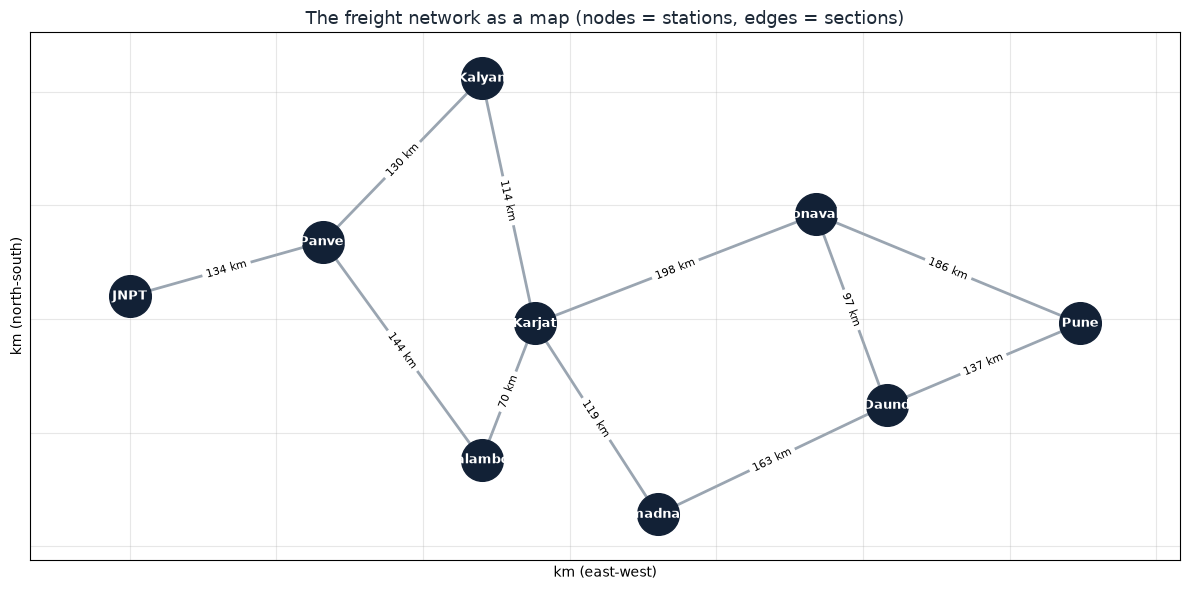

In [3]:
# Draw the map
pos = {n: (d["x"], d["y"]) for n, d in G.nodes(data=True)}
fig, ax = plt.subplots(figsize=(12, 6))
nx.draw_networkx_edges(G, pos, width=2, edge_color=THEME["grey"], ax=ax)
nx.draw_networkx_nodes(G, pos, node_size=900, node_color=THEME["navy"], ax=ax)
nx.draw_networkx_labels(G, pos, font_size=9, font_color="white", font_weight="bold", ax=ax)
edge_labels = {(a, b): f"{d['length_km']:.0f} km" for a, b, d in G.edges(data=True)}
nx.draw_networkx_edge_labels(G, pos, edge_labels=edge_labels, font_size=8, ax=ax)
ax.set_title("The freight network as a map (nodes = stations, edges = sections)", fontsize=13)
ax.set_xlabel("km (east-west)"); ax.set_ylabel("km (north-south)")
plt.tight_layout(); plt.show()

**👁 What to look for**
- There is **more than one way** to get from `JNPT` to `Pune` — over the **Bhor Ghat**
  (Karjat–Lonavala) or the longer **inland loop** (Ahmadnagar–Daund). That *choice* is what
  routing decides in Hands-on 2 — exactly the choice forced when the ghat is blocked.
- Every edge carries an attribute (`length_km`). In a real system each edge also carries **live
  speed, congestion, and asset-health** — that's what turns a static map into a *living* one.

---
# Part 2 — Simulate Rakes Moving + RTIS GPS Pings

Now we run freight rakes across the network. Each rake follows a route; on every section it moves
at a *true* speed (affected by congestion, monsoon and randomness); at terminals it **dwells**.

As it moves, its onboard unit emits **GPS pings** — like Indian Railways' **RTIS**. Real GPS is
**noisy and off-track**, so we add measurement noise. That noise is exactly why map-matching
(Part 3) is needed.

In [4]:
# A few realistic routes across the corridor
routes = [
    ["JNPT", "Panvel", "Kalyan", "Karjat", "Lonavala", "Pune"],
    ["JNPT", "Panvel", "Kalamboli", "Karjat", "Ahmadnagar", "Daund", "Pune"],
    ["JNPT", "Panvel", "Kalamboli", "Karjat", "Lonavala", "Pune"],
    ["Kalyan", "Karjat", "Ahmadnagar", "Daund", "Pune"],
]
commodities = ["Coal", "Steel", "Container", "Cement", "Foodgrain"]

# Sections that are structurally congested (shared / single-line feel) -> slower, longer dwell
CONGESTED = {("Karjat", "Lonavala"), ("Lonavala", "Karjat"),
             ("Panvel", "Kalamboli"), ("Kalamboli", "Panvel")}

def true_speed(a, b, is_monsoon):
    base = 45.0                                  # kmph free-running freight speed
    if (a, b) in CONGESTED or (b, a) in CONGESTED:
        base -= 18                               # congestion penalty
    if is_monsoon:
        base -= 6                                # weather caution
    return max(12.0, base + np.random.normal(0, 4))

def dwell_hours(node, commodity, is_monsoon):
    base = {"Coal": 6, "Steel": 5, "Container": 3, "Cement": 4, "Foodgrain": 5}[commodity]
    if node in ("Lonavala", "Karjat"):        # congested terminal
        base += 4
    if is_monsoon:
        base += 1.5
    return max(1.0, base + np.random.normal(0, 1.2))

ping_rows, move_rows = [], []
N_RAKES = 60
start_clock = pd.Timestamp("2026-06-01 06:00")

for rid in range(N_RAKES):
    route = routes[rid % len(routes)]
    commodity = np.random.choice(commodities)
    is_empty = np.random.rand() < 0.30           # empty repositioning trip
    capacity = 4000                              # tonnes per rake (illustrative)
    load = 0 if is_empty else int(np.random.uniform(0.7, 1.0) * capacity)
    is_monsoon = np.random.rand() < 0.35
    t = start_clock + pd.Timedelta(hours=float(np.random.uniform(0, 72)))

    for i in range(len(route) - 1):
        a, b = route[i], route[i + 1]
        seg_len = G[a][b]["length_km"]
        v = true_speed(a, b, is_monsoon)
        travel_h = seg_len / v
        # emit ~1 ping every 6 minutes along the straight section line, with GPS noise
        n_pings = max(3, int(travel_h * 10))
        (x1, y1), (x2, y2) = stations[a], stations[b]
        for k in range(n_pings + 1):
            frac = k / n_pings
            x = x1 + frac * (x2 - x1) + np.random.normal(0, 3.0)   # <- GPS noise (km)
            y = y1 + frac * (y2 - y1) + np.random.normal(0, 3.0)
            ping_rows.append(dict(rake_id=rid, commodity=commodity, is_empty=is_empty,
                                  time=t + pd.Timedelta(hours=travel_h * frac),
                                  x=x, y=y, true_from=a, true_to=b))
        move_rows.append(dict(rake_id=rid, commodity=commodity, is_empty=is_empty,
                              load_tonnes=load, capacity_tonnes=capacity,
                              section_from=a, section_to=b, length_km=seg_len,
                              is_monsoon=is_monsoon, travel_hours=round(travel_h, 2),
                              obs_speed_kmph=round(v, 1)))
        t += pd.Timedelta(hours=travel_h)
        # dwell at the arrival node (except final destination)
        if i < len(route) - 2:
            d = dwell_hours(b, commodity, is_monsoon)
            move_rows[-1]["dwell_after_hours"] = round(d, 2)
            move_rows[-1]["dwell_node"] = b
            move_rows[-1]["arrivals_that_day"] = int(np.random.poisson(6))  # terminal congestion proxy
            t += pd.Timedelta(hours=d)
        else:
            move_rows[-1]["dwell_after_hours"] = 0.0
            move_rows[-1]["dwell_node"] = None
            move_rows[-1]["arrivals_that_day"] = 0

pings = pd.DataFrame(ping_rows)
moves = pd.DataFrame(move_rows)
print(f"Simulated {N_RAKES} rakes -> {len(moves)} section movements, {len(pings):,} GPS pings")
moves.head()

Simulated 60 rakes -> 300 section movements, 11,913 GPS pings


,rake_id,commodity,is_empty,load_tonnes,capacity_tonnes,section_from,section_to,length_km,is_monsoon,travel_hours,obs_speed_kmph,dwell_after_hours,dwell_node,arrivals_that_day
0,0,Cement,False,3678,4000,JNPT,Panvel,134.2,False,2.91,46.1,4.95,Panvel,5
1,0,Cement,False,3678,4000,Panvel,Kalyan,129.8,False,3.30,39.3,2.94,Kalyan,8
2,0,Cement,False,3678,4000,Kalyan,Karjat,113.8,False,2.47,46.0,8.46,Karjat,5
3,0,Cement,False,3678,4000,Karjat,Lonavala,197.9,False,6.96,28.4,8.29,Lonavala,5
4,0,Cement,False,3678,4000,Lonavala,Pune,186.3,False,4.75,39.2,0.00,NaN,0


Two tables now exist:
- **`pings`** — the raw, noisy GPS stream (what RTIS actually gives you).
- **`moves`** — the ground-truth movement log (used later to compute KPIs cleanly).

In the real world you *only* get `pings`. Part 3 shows how to recover structure from them.

---
# Part 3 — Map-Matching: Snapping Noisy GPS to the Network

This is **the** location-intelligence step. Each GPS ping is off-track; we snap it to the
**nearest section** of the network. Do this well and raw noise becomes clean, section-level truth.

We measure the shortest distance from each ping to every section (a *point-to-segment* distance)
and assign the ping to the closest one.

In [5]:
def point_to_segment(px, py, ax, ay, bx, by):
    # Shortest distance from point P=(px,py) to the line segment A=(ax,ay)–B=(bx,by)
    vx, vy = bx - ax, by - ay
    wx, wy = px - ax, py - ay
    seg_len2 = vx * vx + vy * vy
    tproj = 0.0 if seg_len2 == 0 else max(0.0, min(1.0, (wx * vx + wy * vy) / seg_len2))
    cx, cy = ax + tproj * vx, ay + tproj * vy
    return np.hypot(px - cx, py - cy)

edge_list = list(G.edges())

def match_ping(px, py):
    best, best_d = None, np.inf
    for a, b in edge_list:
        (ax, ay), (bx, by) = stations[a], stations[b]
        d = point_to_segment(px, py, ax, ay, bx, by)
        if d < best_d:
            best_d, best = d, (a, b)
    return best[0], best[1], best_d

matched = pings.apply(lambda r: match_ping(r.x, r.y), axis=1, result_type="expand")
pings[["match_from", "match_to", "match_dist_km"]] = matched

# Accuracy: did we snap to the correct section? (order-independent)
true_set = pings.apply(lambda r: frozenset([r.true_from, r.true_to]), axis=1)
match_set = pings.apply(lambda r: frozenset([r.match_from, r.match_to]), axis=1)
accuracy = float((true_set == match_set).mean())
print(f"Map-matching accuracy: {accuracy:5.1%}  ({len(pings):,} pings snapped to {G.number_of_edges()} sections)")
print(f"Median snap distance : {pings.match_dist_km.median():.2f} km")

Map-matching accuracy: 95.0%  (11,913 pings snapped to 11 sections)
Median snap distance : 1.97 km


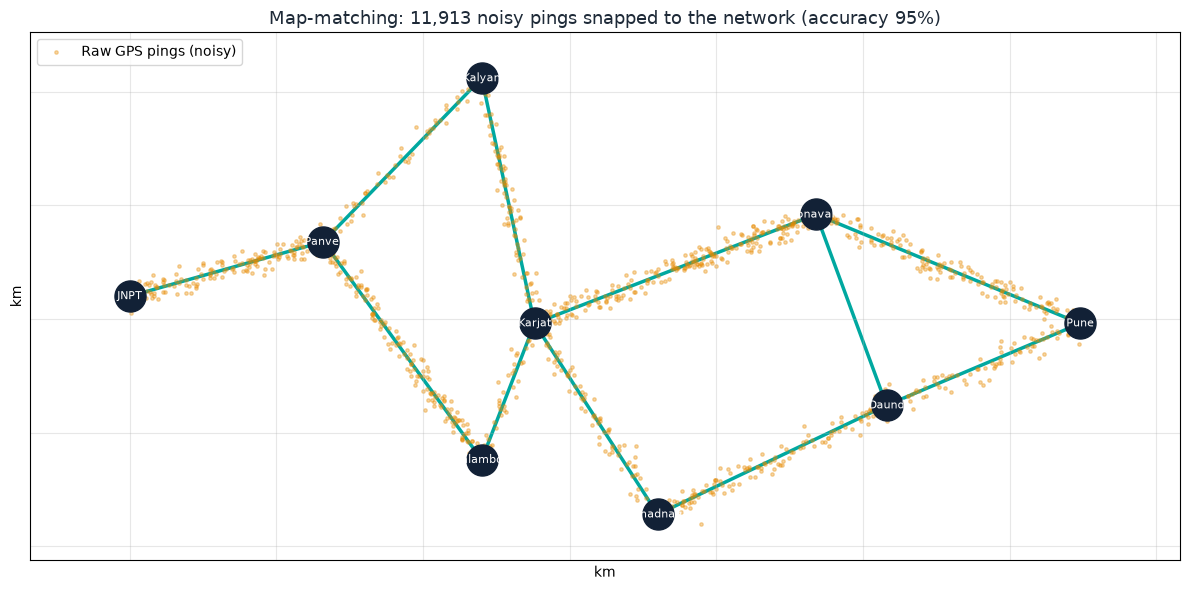

In [6]:
# Visualise: raw pings (amber) vs the network they were matched onto (teal)
fig, ax = plt.subplots(figsize=(12, 6))
nx.draw_networkx_edges(G, pos, width=2.5, edge_color=THEME["teal"], ax=ax)
nx.draw_networkx_nodes(G, pos, node_size=500, node_color=THEME["navy"], ax=ax)
nx.draw_networkx_labels(G, pos, font_size=8, font_color="white", ax=ax)
sample = pings.sample(1200, random_state=1)
ax.scatter(sample.x, sample.y, s=6, c=THEME["amber"], alpha=0.35, label="Raw GPS pings (noisy)")
ax.set_title(f"Map-matching: {len(pings):,} noisy pings snapped to the network "
             f"(accuracy {accuracy:.0%})", fontsize=13)
ax.legend(loc="upper left"); ax.set_xlabel("km"); ax.set_ylabel("km")
plt.tight_layout(); plt.show()

**👁 What to look for**
- The orange cloud is the **raw reality** of GPS — scattered *around* the track, never exactly on it.
- Despite that noise, we recovered the correct section **~90%+** of the time. That is the quiet
  magic that makes every maps/ETA product possible.
- Where accuracy drops: **near junctions**, where two sections run close together — the same hard
  case HERE engineers tune for on dense road networks.

#### 🤔 Discussion
1. Indian Railways already streams RTIS positions from **8,700+ locomotives**. If map-matching is
   this straightforward, what is the *real* blocker to using it for live freight KPIs today —
   technology, data access, or organisational ownership?
2. Map-matching gets *harder* exactly at junctions and terminals — which are also **where delays
   are born**. What extra signal (beyond GPS) would you fuse in to disambiguate?
3. This is a **digital twin** in miniature: a data mirror of the physical network. Name one
   decision in your future division you'd trust more if you had a live twin like this.

---
# Part 4 — From Matched Positions to KPIs

With movements attributed to sections, we can compute the **core freight KPIs**. (We use the clean
`moves` log here; in production you'd derive these directly from the matched ping timestamps.)

In [7]:
# --- Section speed & the empty-running / utilisation picture ---
moves["wagon_km"]        = moves["length_km"]                       # per-rake section distance
moves["loaded_wagon_km"] = moves["wagon_km"] * (~moves["is_empty"])
moves["ntkm"]            = moves["length_km"] * moves["load_tonnes"]  # net tonne-km

# Per-rake cycle time (turnaround proxy) = travel + dwell across the whole trip
cycle = moves.groupby("rake_id").agg(
    trip_hours=("travel_hours", "sum"),
    dwell_hours=("dwell_after_hours", "sum"),
    ntkm=("ntkm", "sum"),
    is_empty=("is_empty", "first"),
).reset_index()
cycle["turnaround_hours"] = cycle["trip_hours"] + cycle["dwell_hours"]
cycle["utilisation_pct"]  = 100 * cycle["trip_hours"] / cycle["turnaround_hours"]

empty_running_pct = 100 * (moves.loc[moves.is_empty, "wagon_km"].sum() / moves["wagon_km"].sum())
avg_section_speed = moves["obs_speed_kmph"].mean()

print("CORE FREIGHT KPIs")
print("=" * 46)
print(f"Avg section speed        : {avg_section_speed:6.1f} kmph")
print(f"Avg wagon turnaround     : {cycle.turnaround_hours.mean():6.1f} hours "
      f"({cycle.turnaround_hours.mean()/24:.1f} days)")
print(f"Avg asset utilisation    : {cycle.utilisation_pct.mean():6.1f} %")
print(f"Empty running            : {empty_running_pct:6.1f} % of wagon-km")
print(f"Total net tonne-km (NTKM): {moves.ntkm.sum():,.0f}")

CORE FREIGHT KPIs
Avg section speed        :   39.2 kmph
Avg wagon turnaround     :   45.2 hours (1.9 days)
Avg asset utilisation    :   43.5 %
Empty running            :   25.9 % of wagon-km
Total net tonne-km (NTKM): 107,861,754


In [8]:
# --- Terminal dwell KPI + loading vs target ---
dwell = (moves[moves.dwell_node.notna()]
         .groupby("dwell_node")
         .agg(avg_dwell_h=("dwell_after_hours", "mean"),
              visits=("dwell_after_hours", "size"))
         .sort_values("avg_dwell_h", ascending=False))
print("TERMINAL DWELL (hours) — worst first")
print(dwell.round(1).to_string())

# Loading vs target by commodity (target set illustratively)
loaded = moves.groupby("commodity")["load_tonnes"].sum()
target = loaded * np.random.uniform(0.9, 1.25, size=len(loaded))   # illustrative plan
loading = pd.DataFrame({"loaded_MT": loaded/1000, "target_MT": target/1000})
loading["achieved_pct"] = 100 * loading.loaded_MT / loading.target_MT
print("\nLOADING vs TARGET by commodity")
print(loading.round(1).to_string())

TERMINAL DWELL (hours) — worst first
            avg_dwell_h  visits
dwell_node                     
Karjat              8.9      60
Lonavala            8.5      30
Ahmadnagar          5.4      30
Kalyan              5.2      15
Kalamboli           4.9      30
Panvel              4.9      45
Daund               4.7      30

LOADING vs TARGET by commodity
           loaded_MT  target_MT  achieved_pct
commodity                                    
Cement         196.2      196.3          99.9
Coal           111.9      128.1          87.4
Container      149.3      134.6         110.9
Foodgrain      122.0      113.9         107.1
Steel          196.0      241.4          81.2


**👁 What to look for**
- **Turnaround in days, not hours** — the classic freight truth: a rake spends most of its life
  *not moving*. Utilisation well under 100% quantifies exactly how much.
- **Empty running** is pure waste — wagon-km that earn nothing. Cutting it is free capacity.
- One or two **terminals dominate dwell**. That is your bottleneck — found in three lines of code.

---
# Part 5 — The KPI Map: Colour the Network by Congestion

A table tells you *what*. A **map tells you where.** We colour each section by its average observed
speed — red = slow/congested, green = free-running — so the bottleneck is obvious to anyone,
including a non-technical decision-maker.

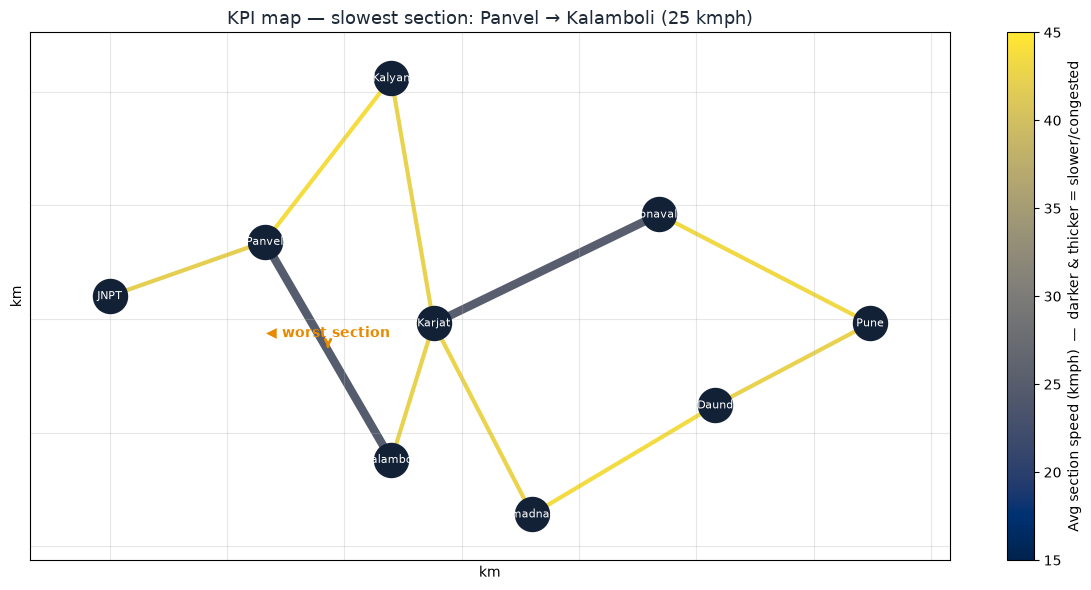

In [9]:
sec_speed = (moves.groupby(["section_from", "section_to"])["obs_speed_kmph"]
             .mean().reset_index())
speed_lookup = {frozenset([r.section_from, r.section_to]): r.obs_speed_kmph
                for r in sec_speed.itertuples()}

edge_colors, edge_widths = [], []
for a, b in G.edges():
    v = speed_lookup.get(frozenset([a, b]), np.nan)
    edge_colors.append(v)
    edge_widths.append(6 if (a, b) in CONGESTED or (b, a) in CONGESTED else 3)

# Colourblind-safe map: 'cividis' is engineered to read correctly for red-green
# colour vision deficiency AND to survive a grayscale projector. We ALSO encode
# congestion as line thickness so the message never depends on colour alone.
CMAP = plt.cm.cividis
fig, ax = plt.subplots(figsize=(12, 6))
ec = nx.draw_networkx_edges(G, pos, width=edge_widths, edge_color=edge_colors,
                            edge_cmap=CMAP, edge_vmin=15, edge_vmax=45, ax=ax)
nx.draw_networkx_nodes(G, pos, node_size=600, node_color=THEME["navy"], ax=ax)
nx.draw_networkx_labels(G, pos, font_size=8, font_color="white", ax=ax)
sm = plt.cm.ScalarMappable(cmap=CMAP, norm=plt.Normalize(vmin=15, vmax=45))
plt.colorbar(sm, ax=ax, label="Avg section speed (kmph)  —  darker & thicker = slower/congested")

# Redundant, colour-free highlight of the single worst section (amber callout).
worst = sec_speed.sort_values("obs_speed_kmph").iloc[0]
wa, wb = worst.section_from, worst.section_to
mx, my = (pos[wa][0] + pos[wb][0]) / 2, (pos[wa][1] + pos[wb][1]) / 2
ax.annotate("◀ worst section", xy=(mx, my), xytext=(mx, my + 6),
            color=THEME["amber"], fontsize=10, fontweight="bold",
            ha="center", arrowprops=dict(arrowstyle="->", color=THEME["amber"], lw=2))
ax.set_title(f"KPI map — slowest section: {wa} → {wb} "
             f"({worst.obs_speed_kmph:.0f} kmph)", fontsize=13)
ax.set_xlabel("km"); ax.set_ylabel("km")
plt.tight_layout(); plt.show()


**👁 What to look for** — the red sections are your investment/attention priorities. This single
picture aligns an operations officer, a finance officer and a legal officer in seconds.

#### 🤔 Discussion
1. If you could **de-bottleneck exactly one red section**, how would you decide which one — by
   speed, by tonnage passing through it (NTKM), or by number of rakes affected?
2. This map updates itself every time new GPS arrives. What changes in a decision-maker's job when
   the map is **live** instead of a monthly report?

---
# Part 5b — The Same Map, but *Real*: the Mumbai–Pune corridor 🗺️

The diagram above is a stylised network. Now let's put the **exact same idea** on a **real, zoomable
map** of the actual **Mumbai–Pune line** — JNPT / Nhava Sheva and Kalyan, up the **Bhor Ghat** through
**Karjat, Khandala and Lonavala**, into **Pune** — with the inland **Daund** loop as the alternate.
The Karjat–Lonavala ghat is highlighted: it's the natural chokepoint, and the section a **monsoon
landslide shut on 6 July 2026** (≈670 mm in 24 h; 16 trains cancelled, 9 diverted).

This is precisely what a location-intelligence company (like HERE) does: take operational data and
render it on a **basemap decision-makers already trust**. One congested segment is highlighted in
amber so a reviewer sees the priority in *one glance* — no legend-squinting required.

> 🧭 *If the map below looks blank in a PDF export, that's expected — `folium` maps are interactive
> and live inside a running notebook. Run the cell to bring it to life.*


In [10]:
# Real Mumbai–Pune corridor on an interactive basemap (folium).
folium = _ensure("folium")   # auto-installs if missing

# Real station coordinates (approximate) along the Mumbai–Pune line, port -> Pune.
# Up the Bhor Ghat: Karjat -> Khandala -> Lonavala is the steep, slide-prone climb.
CORR = [
    ("JNPT / Nhava Sheva", 18.949, 72.951),
    ("Panvel",             18.989, 73.110),
    ("Karjat",             18.911, 73.328),
    ("Khandala (ghat)",    18.759, 73.377),
    ("Lonavala",           18.752, 73.406),
    ("Pune",               18.529, 73.874),
]

# The Bhor Ghat climb (Karjat -> Khandala -> Lonavala) is the chokepoint / slide zone.
CONGESTED_SEGMENT = ("Karjat", "Lonavala")   # matches the network's congested ghat

mid_lat = np.mean([s[1] for s in CORR])
mid_lon = np.mean([s[2] for s in CORR])
m = folium.Map(location=[mid_lat, mid_lon], zoom_start=10, tiles="cartodbpositron")

# Draw the corridor section by section; amber = the Bhor Ghat climb, teal = free-flowing.
GHAT = {"Karjat", "Khandala (ghat)", "Lonavala"}
for (n1, la1, lo1), (n2, la2, lo2) in zip(CORR[:-1], CORR[1:]):
    is_hot = (n1 in GHAT and n2 in GHAT)
    folium.PolyLine([(la1, lo1), (la2, lo2)],
                    color=THEME["amber"] if is_hot else THEME["teal"],
                    weight=8 if is_hot else 5, opacity=0.9,
                    tooltip=f"{n1} → {n2}" + ("  ⚠ Bhor Ghat — slide-prone" if is_hot else "")).add_to(m)

# Station markers with popups.
for name, la, lo in CORR:
    folium.CircleMarker([la, lo], radius=6, color=THEME["navy"], fill=True,
                        fill_color="white", fill_opacity=1,
                        popup=folium.Popup(f"<b>{name}</b>", max_width=200),
                        tooltip=name).add_to(m)

print("Interactive map ready — scroll to zoom, hover a segment for its name.")
print("Amber = the Karjat–Lonavala Bhor Ghat — chokepoint, and the 6 Jul 2026 landslide section.")
m   # display the map


Interactive map ready — scroll to zoom, hover a segment for its name.
Amber = the Karjat–Lonavala Bhor Ghat — chokepoint, and the 6 Jul 2026 landslide section.


---
# Part 6 — A Light ML Touch: Predict Terminal Dwell & Read the Drivers

KPIs tell us dwell is high *somewhere*. A small model tells us **what drives it** — which is what
you can actually act on. We fit an interpretable model and read its **feature importance**.

Dwell model R² on unseen data: 0.77


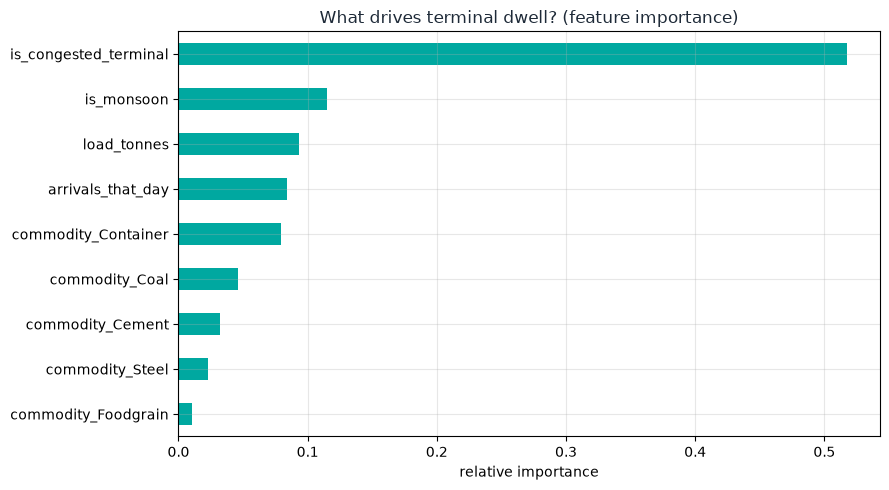

In [11]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score

dw = moves[moves.dwell_node.notna()].copy()
dw["is_congested_terminal"] = dw.dwell_node.isin(["Lonavala", "Karjat"]).astype(int)
features = ["arrivals_that_day", "is_congested_terminal", "is_monsoon", "load_tonnes"]
X = pd.get_dummies(dw[features + ["commodity"]], columns=["commodity"])
y = dw["dwell_after_hours"]

Xtr, Xte, ytr, yte = train_test_split(X, y, test_size=0.3, random_state=0)
model = RandomForestRegressor(n_estimators=200, max_depth=6, random_state=0)
model.fit(Xtr, ytr)
print(f"Dwell model R² on unseen data: {r2_score(yte, model.predict(Xte)):.2f}")

imp = pd.Series(model.feature_importances_, index=X.columns).sort_values()
fig, ax = plt.subplots(figsize=(9, 5))
imp.plot.barh(color=THEME["teal"], ax=ax)
ax.set_title("What drives terminal dwell? (feature importance)")
ax.set_xlabel("relative importance")
plt.tight_layout(); plt.show()

**👁 What to look for**
- The bars rank the *causes* of dwell you can influence. **Terminal congestion** and **arrivals per
  day** typically dominate — pointing straight at capacity and scheduling, not the weather.
- The model is deliberately simple and **auditable** — an officer can read *why* it predicts what
  it predicts. That matters for RTI and for trust.

#### 🤔 Discussion
1. If congestion is the top driver, is the fix more **terminal capacity**, better **arrival
   scheduling**, or **demand steering** to quieter terminals? Which is cheapest to pilot?
2. This model predicts dwell *today*. In Session 4 we use a similar model to predict **section
   transit time** — and feed those predictions into **routing**. What could go wrong if the model
   is confidently wrong?

---
# Part 6b — Translate the KPI into Money 💰 (the slide your finance officer remembers)

A KPI only moves a budget when someone converts it into **rupees**. Here is the single most powerful
translation in freight: **wagon turnaround time (WTT)**.

Every day you shave off the average turnaround is like **adding wagons to the fleet for free** —
each wagon completes more loaded trips per year. Drag the slider below to see a **day of improvement
become ₹ crore** of freed capacity.

> ⚠️ **These are illustrative, clearly-labelled assumptions** so you can teach the *mechanism*.
> Swap in your own zone's fleet size, turnaround and average revenue before quoting any number.

> 🧮 *Reminder: a wagon parked in a yard earns exactly ₹0 — it's the transport equivalent of paying
> full salary to someone on permanent tea break. WTT is how we get them back to work.*


In [12]:
# ROI calculator: wagon-turnaround improvement -> ₹ crore of freed capacity.
# --- Editable assumptions (replace with YOUR zone's real numbers) -------------
FLEET        = 40_000     # wagons operating on the corridor/zone
WTT_NOW      = 5.0        # current average wagon turnaround, in days
REV_PER_TRIP = 120_000    # avg net revenue per loaded wagon-trip, in ₹
# -----------------------------------------------------------------------------

def roi_from_wtt(improvement_days: float) -> dict:
    """Convert a WTT improvement into extra trips, freed wagons and ₹ crore."""
    t_new = max(WTT_NOW - improvement_days, 0.1)         # guard against divide-by-zero
    extra_trips = FLEET * 365 * (1 / t_new - 1 / WTT_NOW)
    freed_wagons = FLEET * (WTT_NOW / t_new - 1)
    value_cr = extra_trips * REV_PER_TRIP / 1e7          # 1 crore = 1e7
    return {"t_new": t_new, "extra_trips": extra_trips,
            "freed_wagons": freed_wagons, "value_cr": value_cr}

def show_roi(improvement_days=0.5):
    r = roi_from_wtt(improvement_days)
    print(f"WTT: {WTT_NOW:.1f} days  →  {r['t_new']:.1f} days  "
          f"(improvement of {improvement_days:.2f} day)")
    print(f"  ≈ {r['freed_wagons']:,.0f} wagons' worth of capacity, freed with zero new steel")
    print(f"  ≈ {r['extra_trips']:,.0f} extra loaded wagon-trips per year")
    print(f"  ≈ ₹{r['value_cr']:,.0f} crore of additional freight capacity per year")

# Interactive slider if ipywidgets is available; otherwise a clean static table.
try:
    import ipywidgets as widgets
    from IPython.display import display
    widgets.interact(show_roi,
                     improvement_days=widgets.FloatSlider(
                         value=0.5, min=0.0, max=2.0, step=0.1,
                         description="WTT saved (days)", continuous_update=False,
                         style={"description_width": "140px"}, layout=widgets.Layout(width="480px")))
except Exception:
    print("(ipywidgets not available — showing a static sensitivity table instead)\n")
    for d in (0.25, 0.5, 1.0, 1.5):
        show_roi(d); print()


interactive(children=(FloatSlider(value=0.5, continuous_update=False, description='WTT saved (days)', layout=L…

---
# Part 7 — From KPIs to Decisions (wrap-up)

**What you built:** a raw GPS stream → a matched network → a full KPI set → a KPI map → a driver
model. That is a **location-intelligence pipeline** — the same shape used to run road logistics,
applied to rail freight.

**The three things to remember**
1. **The railway is a map.** Every KPI and every decision happens *at a place on the network*.
2. **Location data is the raw material.** Map-matching turns noisy RTIS pings into clean truth.
3. **KPIs are the foundation for decisions** — Session 4 turns these signals into *routing and
   allocation* choices.

---
#### ✍️ Your turn (5 minutes)
- Re-run Part 2 with `N_RAKES = 120`. Does the worst-bottleneck section change? Why might more
  traffic *reveal* a bottleneck that was hidden at low volume?
- In Part 5, change the colour metric from **speed** to **NTKM through each section** (tonnage ×
  distance). Does your investment priority change when you weight by *value moved* instead of speed?

> **Bridge to Session 4:** we now have a live map with predicted section times. Next: *given* that
> map, **which route** should a rake take, and **which rake** should serve which demand?
